In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


In [2]:
df = pd.read_csv("DATASET\Crop_yield_prediction\yield_df.csv")

df.head()

<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Abim Putra\AppData\Local\Temp\ipykernel_6524\514459021.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv("DATASET\Crop_yield_prediction\yield_df.csv")


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


----------------------------------------------PREPROCESSING DATA-----------------------------------------------------------

In [3]:
# Check for missing values and data types
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [4]:
# Define features and target variable
X = df.drop(columns=["hg/ha_yield"])
y = df["hg/ha_yield"]

# Define numeric and categorical features
numeric_features = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

categorical_features = [
    "Area",
    "Item"
]


In [5]:
# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ]
)


In [6]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [7]:
X_train_processed_base = preprocessor.fit_transform(X_train)
X_test_processed_base = preprocessor.transform(X_test)


In [8]:
print("X_train:", X_train_processed_base.shape)
print("X_test :", X_test_processed_base.shape)


X_train: (22593, 113)
X_test : (5649, 113)


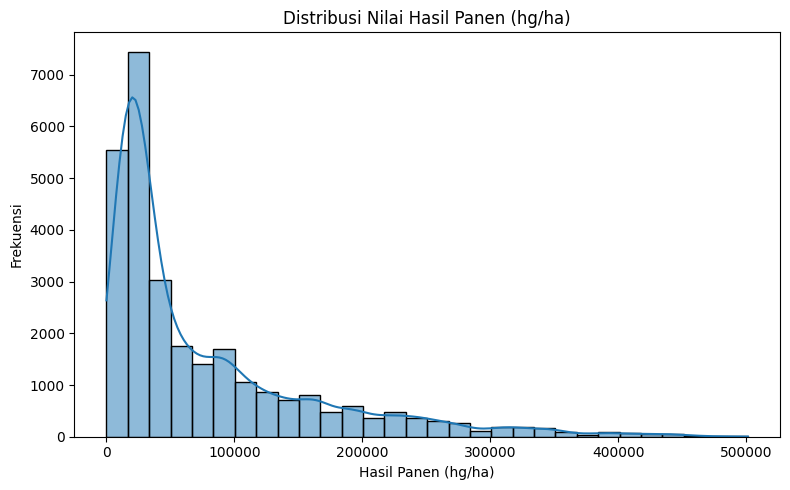

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["hg/ha_yield"], bins=30, kde=True)
plt.title("Distribusi Nilai Hasil Panen (hg/ha)")
plt.xlabel("Hasil Panen (hg/ha)")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()


------------------------------------------------BASELINE MODELLING------------------------------------------------------

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [11]:
def get_models_regression() :
    return {
    "Linear Regression": LinearRegression(),
    
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
        ),
    
    "XGBoost Regressor": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        random_state=42
        )
}


In [12]:
models_reg_baseline = get_models_regression()

trained_models_reg_baseline = {}
results_reg_base = []

In [13]:
results_reg_base = []

for name, model in models_reg_baseline.items():
    # Train
    model.fit(X_train_processed_base, y_train)
    trained_models_reg_baseline[name] = model
    
    # Predict
    y_pred = model.predict(X_test_processed_base)
    
    # Evaluasi
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results_reg_base.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_reg_df_base = pd.DataFrame(results_reg_base).sort_values(by="RMSE")

results_reg_df_base


,Model,MAE,RMSE,R2 Score
1,Random Forest Regressor,3457.294164,9486.672243,0.987593
2,XGBoost Regressor,8232.249023,14299.164171,0.971812
0,Linear Regression,29582.463967,42143.976163,0.755143


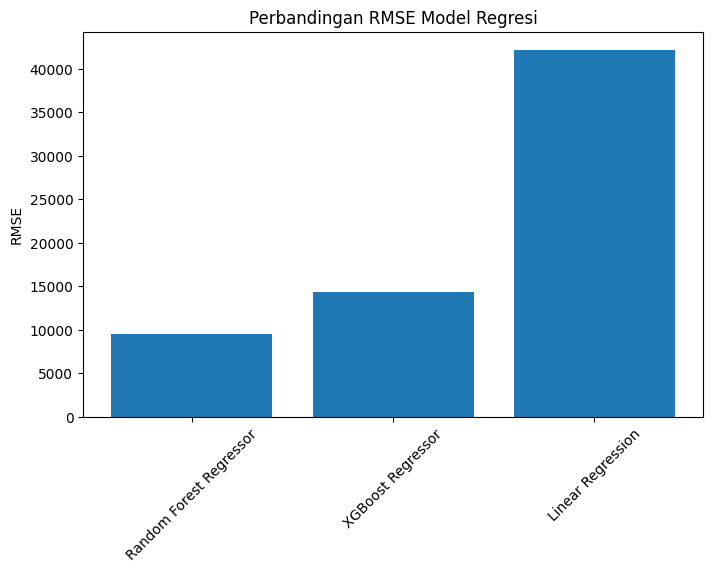

In [14]:
plt.figure(figsize=(8,5))
plt.bar(results_reg_df_base["Model"], results_reg_df_base["RMSE"])
plt.ylabel("RMSE")
plt.title("Perbandingan RMSE Model Regresi")
plt.xticks(rotation=45)
plt.show()


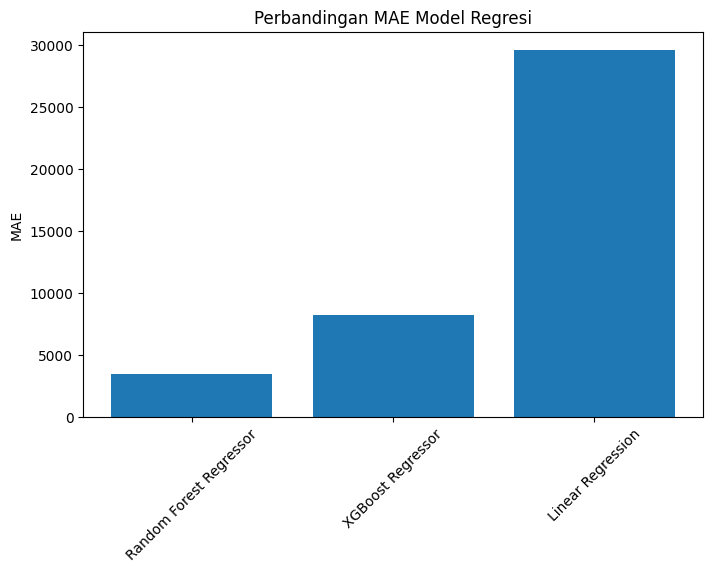

In [15]:
plt.figure(figsize=(8,5))
plt.bar(results_reg_df_base["Model"], results_reg_df_base["MAE"])
plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.title("Perbandingan MAE Model Regresi")
plt.show()

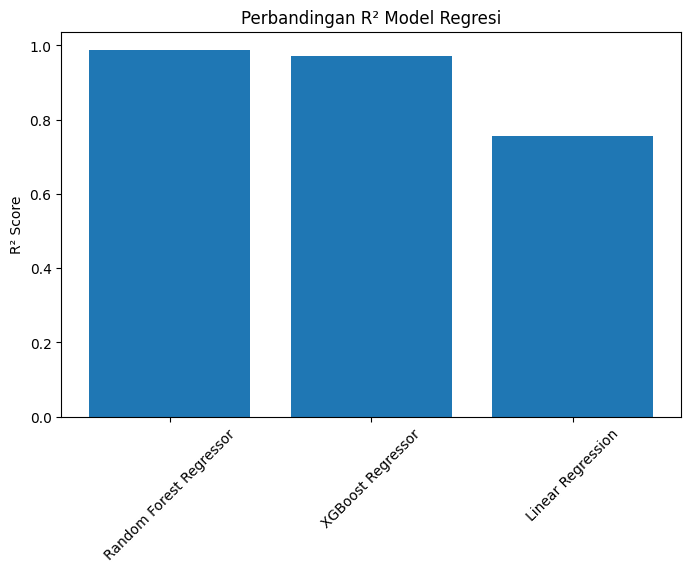

In [16]:
plt.figure(figsize=(8,5))
plt.bar(results_reg_df_base["Model"], results_reg_df_base["R2 Score"])
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Perbandingan R² Model Regresi")
plt.show()

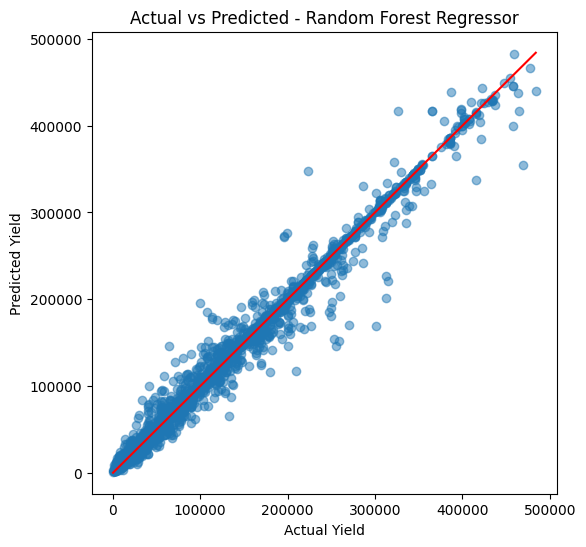

In [17]:
best_model_name = results_reg_df_base.iloc[0]["Model"]
best_model = models_reg_baseline[best_model_name]

y_pred_best = best_model.predict(X_test_processed_base)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.show()


------------------------------------------------FEATURE SELECTION----------------------------------------------------------

Fitur dengan korelasi > 0.8: []


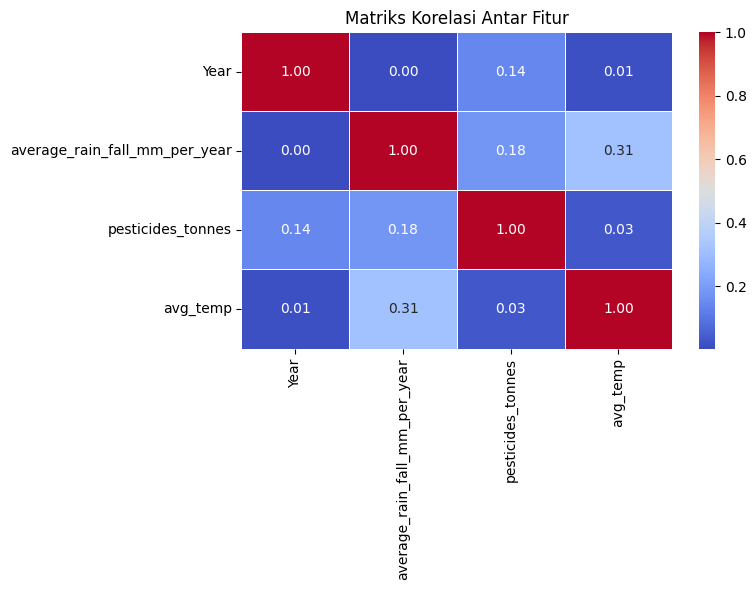

In [18]:
corr_matrix = df[numeric_features].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.8
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print("Fitur dengan korelasi > 0.8:", to_drop)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriks Korelasi Antar Fitur")
plt.tight_layout()
plt.show()

In [19]:
rf_model = trained_models_reg_baseline["Random Forest Regressor"]

In [20]:
feature_names = preprocessor.get_feature_names_out()

In [21]:
feature_importance_reg = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_reg.head(20)

,Feature,Importance
106,cat__Item_Potatoes,0.369278
107,"cat__Item_Rice, paddy",0.074790
2,num__pesticides_tonnes,0.070693
110,cat__Item_Sweet potatoes,0.065419
45,cat__Area_India,0.056951
3,num__avg_temp,0.043609
1,num__average_rain_fall_mm_per_year,0.042474
0,num__Year,0.032830
104,cat__Item_Maize,0.027034
111,cat__Item_Wheat,0.021893


In [22]:
# Ekstrak nama fitur asli dari nama fitur hasil encoding

feature_importance_reg["Original_Feature"] = feature_importance_reg["Feature"].apply(
    lambda x: x.split("__")[1].split("_")[0]  # ambil nama fitur asli
)

importance_grouped = feature_importance_reg.groupby("Original_Feature")["Importance"].sum().sort_values(ascending=False)

importance_grouped_df = importance_grouped.reset_index()
importance_grouped_df.columns = ["Feature", "Total_Importance"]

importance_grouped_df

,Feature,Total_Importance
0,Item,0.611984
1,Area,0.198410
2,pesticides,0.070693
3,avg,0.043609
4,average,0.042474
5,Year,0.032830


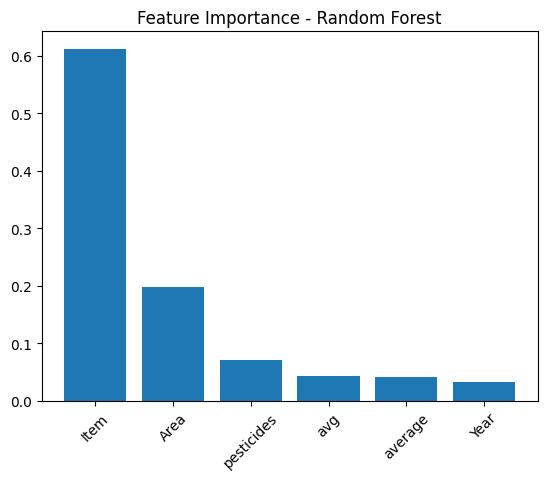

In [23]:
plt.figure()
plt.bar(importance_grouped_df["Feature"], importance_grouped_df["Total_Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance - Random Forest")
plt.show()

In [24]:
numeric_features_fs = [
    col for col in numeric_features
    if col != "Year"
]

numeric_features_fs

['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

In [25]:
preprocessor_fs = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_fs),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ]
)

In [26]:
X_train_fs = preprocessor_fs.fit_transform(X_train)
X_test_fs = preprocessor_fs.transform(X_test)

In [27]:
models_reg_fs = get_models_regression()
results_reg_fs = []
trained_models_reg_fs = {}

In [28]:
results_reg_fs = []

for name, model in models_reg_fs.items():
    model.fit(X_train_fs, y_train)
    trained_models_reg_fs[name] = model

    y_pred = model.predict(X_test_fs)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results_reg_fs.append({
        "Model": name,
        "MAE_noYear": mae,
        "RMSE_noYear": rmse,
        "R2_noYear": r2
    })

fs_year_df = pd.DataFrame(results_reg_fs)
fs_year_df

,Model,MAE_noYear,RMSE_noYear,R2_noYear
0,Linear Regression,29811.607660,42643.985114,0.749298
1,Random Forest Regressor,5495.499485,13725.183003,0.974030
2,XGBoost Regressor,9554.421875,17249.433150,0.958980


In [29]:
comparison_year = results_reg_df_base.merge(fs_year_df, on="Model")

comparison_year["RMSE Change"] = comparison_year["RMSE_noYear"] - comparison_year["RMSE"]
comparison_year["MAE Change"] = comparison_year["MAE_noYear"] - comparison_year["MAE"]
comparison_year["R2 Change"] = comparison_year["R2_noYear"] - comparison_year["R2 Score"]

comparison_year

,Model,MAE,RMSE,R2 Score,MAE_noYear,RMSE_noYear,R2_noYear,RMSE Change,MAE Change,R2 Change
0,Random Forest Regressor,3457.294164,9486.672243,0.987593,5495.499485,13725.183003,0.974030,4238.510759,2038.205321,-0.013563
1,XGBoost Regressor,8232.249023,14299.164171,0.971812,9554.421875,17249.433150,0.958980,2950.268979,1322.172852,-0.012832
2,Linear Regression,29582.463967,42143.976163,0.755143,29811.607660,42643.985114,0.749298,500.008951,229.143694,-0.005845


---------------------------------------LEARNING CURVE-----------------------------------------

In [30]:
from sklearn.model_selection import learning_curve

def plot_learning_curve_regression(model, model_name, X, y):

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # ======================
    # TABEL LEARNING CURVE
    # ======================
    df_lc = pd.DataFrame({
        "Train Size": train_sizes,
        "Train R2": train_mean,
        "Train Std": train_std,
        "Validation R2": val_mean,
        "Validation Std": val_std
    })

    df_lc["Gap"] = df_lc["Train R2"] - df_lc["Validation R2"]

    print(f"\n===== Learning Curve Table - {model_name} =====")
    display(df_lc)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, marker='o', label="Training R²")
    plt.plot(train_sizes, val_mean, marker='o', label="Validation R²")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Size")
    plt.ylabel("R² Score")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df_lc


===== Learning Curve Table - Linear Regression =====


,Train Size,Train R2,Train Std,Validation R2,Validation Std,Gap
0,3614,0.776128,0.004533,0.744878,0.013234,0.031250
1,7229,0.771334,0.005746,0.750739,0.011968,0.020595
2,10844,0.763280,0.002780,0.752296,0.011522,0.010984
3,14459,0.760600,0.003024,0.752929,0.011342,0.007670
4,18074,0.756620,0.002947,0.753412,0.011317,0.003208


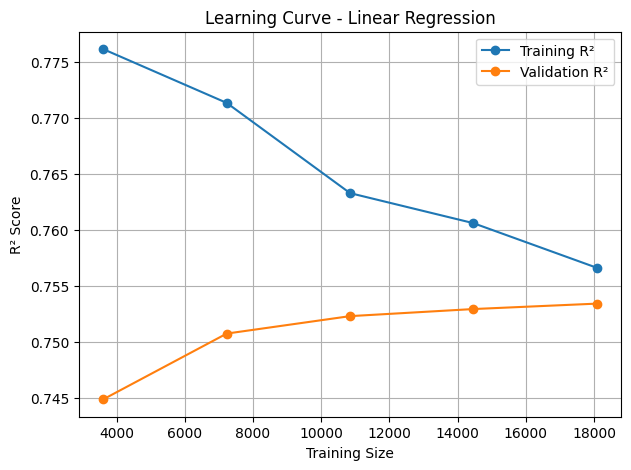


===== Learning Curve Table - Random Forest Regressor =====


,Train Size,Train R2,Train Std,Validation R2,Validation Std,Gap
0,3614,0.992189,0.000023,0.944512,0.005046,0.047677
1,7229,0.995561,0.000264,0.969230,0.004656,0.026330
2,10844,0.996935,0.000121,0.977955,0.002851,0.018980
3,14459,0.997654,0.000057,0.982424,0.001866,0.015230
4,18074,0.997985,0.000063,0.986036,0.001973,0.011949


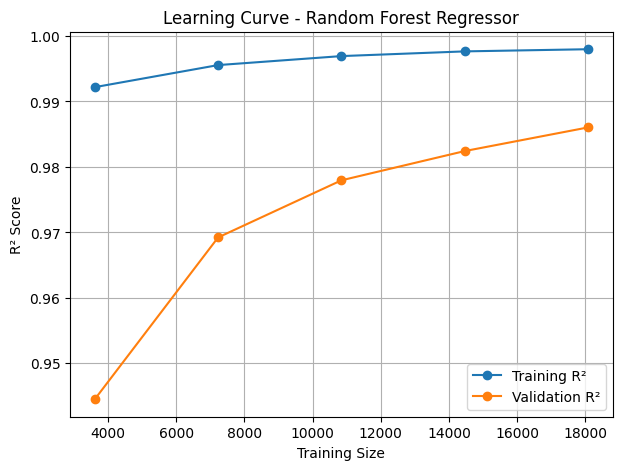


===== Learning Curve Table - XGBoost Regressor =====


,Train Size,Train R2,Train Std,Validation R2,Validation Std,Gap
0,3614,0.983287,0.000160,0.941595,0.004119,0.041692
1,7229,0.980903,0.001179,0.958397,0.003009,0.022506
2,10844,0.978225,0.001016,0.961259,0.003396,0.016966
3,14459,0.979109,0.000374,0.966458,0.002564,0.012651
4,18074,0.978569,0.000657,0.969171,0.002641,0.009398


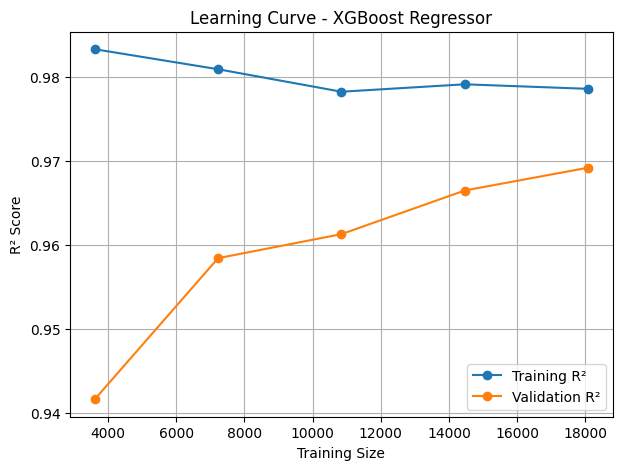

In [31]:
models_reg_baseline = get_models_regression()

for name, model in models_reg_baseline.items():
    plot_learning_curve_regression(
        model,
        name,
        X_train_processed_base,
        y_train
    )

------------------------------------------------------------RM 4-----------------------------------------------------------

In [32]:
from sklearn.model_selection import cross_val_score

cv_results = []

models_reg = get_models_regression()

for name, model in models_reg.items():
    scores = cross_val_score(
        model,
        X_train_processed_base,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Mean": scores.mean(),
        "CV Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
cv_df

,Model,CV Mean,CV Std
0,Linear Regression,0.753412,0.011318
1,Random Forest Regressor,0.986053,0.002001
2,XGBoost Regressor,0.969029,0.002351


In [33]:
train_results = []

for name, model in trained_models_reg_baseline.items():
    y_train_pred = model.predict(X_train_processed_base)
    train_r2 = r2_score(y_train, y_train_pred)

    train_results.append({
        "Model": name,
        "Train R2": train_r2
    })

train_df = pd.DataFrame(train_results)

In [34]:
final_tradeoff_reg = results_reg_df_base.merge(cv_df, on="Model")
final_tradeoff_reg = final_tradeoff_reg.merge(train_df, on="Model")

final_tradeoff_reg["Gap"] = (
    final_tradeoff_reg["Train R2"] - final_tradeoff_reg["R2 Score"]
)
final_tradeoff_reg["Stability Score"] = (
    final_tradeoff_reg["CV Std"] + abs(final_tradeoff_reg["Gap"])
)
final_tradeoff_reg

,Model,MAE,RMSE,R2 Score,CV Mean,CV Std,Train R2,Gap,Stability Score
0,Random Forest Regressor,3457.294164,9486.672243,0.987593,0.986053,0.002001,0.998325,0.010732,0.012733
1,XGBoost Regressor,8232.249023,14299.164171,0.971812,0.969029,0.002351,0.978941,0.007129,0.009480
2,Linear Regression,29582.463967,42143.976163,0.755143,0.753412,0.011318,0.756346,0.001203,0.012521


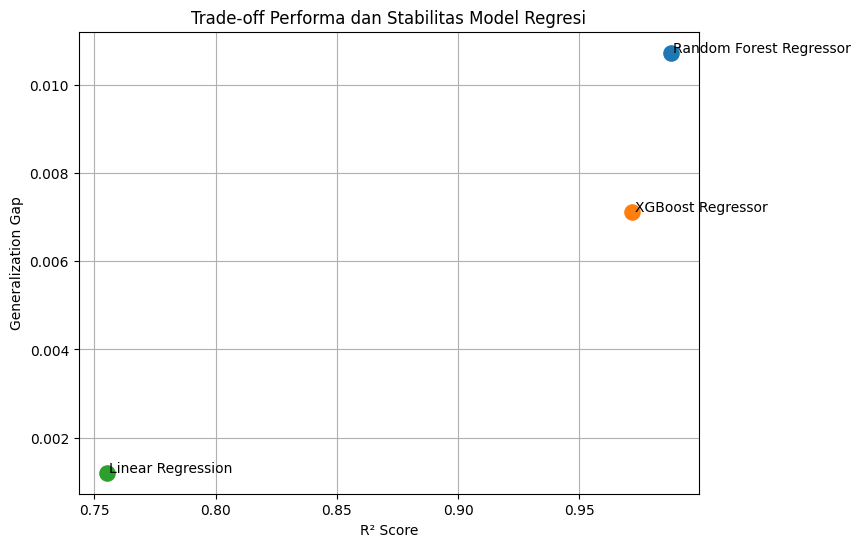

In [35]:
plt.figure(figsize=(8,6))

for i in range(len(final_tradeoff_reg)):
    plt.scatter(
        final_tradeoff_reg["R2 Score"][i],
        final_tradeoff_reg["Gap"][i],
        s=120
    )
    plt.text(
        final_tradeoff_reg["R2 Score"][i] + 0.001,
        final_tradeoff_reg["Gap"][i],
        final_tradeoff_reg["Model"][i]
    )

plt.xlabel("R² Score")
plt.ylabel("Generalization Gap")
plt.title("Trade-off Performa dan Stabilitas Model Regresi")
plt.grid(True)
plt.show()

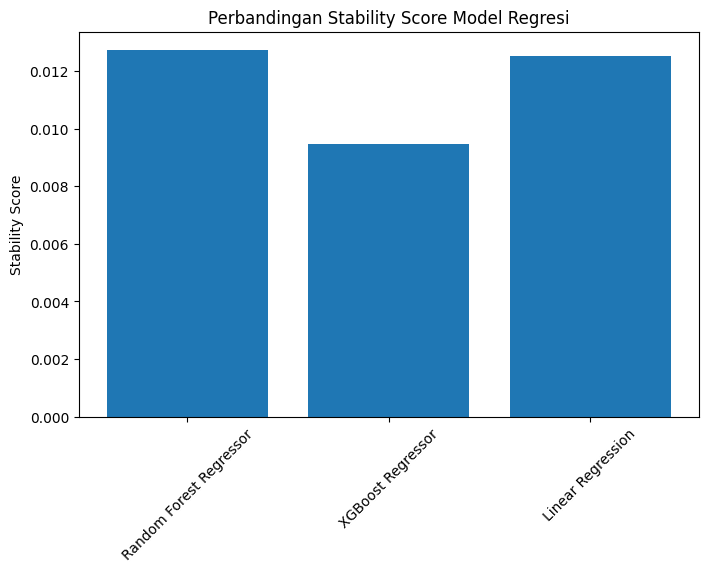

In [38]:
plt.figure(figsize=(8,5))
plt.bar(final_tradeoff_reg["Model"], final_tradeoff_reg["Stability Score"])
plt.xticks(rotation=45)
plt.ylabel("Stability Score")
plt.title("Perbandingan Stability Score Model Regresi")
plt.show()